## 1. Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save model
import joblib

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


## 2. โหลดและทำความสะอาดข้อมูล

In [22]:
# --- โหลดไฟล์ (เลือกวิธีที่เหมาะกับ environment) ---

# Google Colab:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Project_Datasci/scrubbed.csv', low_memory=False)

print(f'Shape: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (80332, 11)


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


###กลยุทธ์การจัดการ Missing Values
shape fillna('unknown')

country fillna('unknown')

state fillna('unknown')

latitude`/`duration coerce to NaN

datetime dropna



In [23]:
# --- จัดการ Missing Values ---
print('Missing values (before):')
print(df.isnull().sum())

df['shape']    = df['shape'].fillna('unknown')
df['country']  = df['country'].fillna('unknown')
df['state']    = df['state'].fillna('unknown')
df['comments'] = df['comments'].fillna('none')

# แปลง duration และ latitude ให้เป็นตัวเลข
df['latitude']            = pd.to_numeric(df['latitude'].astype(str).str.replace('[^0-9.-]','',regex=True), errors='coerce')
df['duration (seconds)']  = pd.to_numeric(df['duration (seconds)'].astype(str).str.replace('[^0-9.-]','',regex=True), errors='coerce')

# แปลง datetime (แก้ 24:00 → 00:00)
df['datetime'] = pd.to_datetime(
    df['datetime'].astype(str).str.replace('24:00','00:00'),
    format='%m/%d/%Y %H:%M',
    errors='coerce'
)

# ลบแถวที่ datetime เป็น NaT
df = df.dropna(subset=['datetime'])
print(f'\nShape after cleaning: {df.shape}')

print('\nMissing values (after):')
print(df.isnull().sum())

Missing values (before):
datetime                   0
city                       0
state                   5797
country                 9670
shape                   1932
duration (seconds)         0
duration (hours/min)       0
comments                  15
date posted                0
latitude                   0
longitude                  0
dtype: int64

Shape after cleaning: (80332, 11)

Missing values (after):
datetime                0
city                    0
state                   0
country                 0
shape                   0
duration (seconds)      0
duration (hours/min)    0
comments                0
date posted             0
latitude                0
longitude               0
dtype: int64


## 3. EDA — การวิเคราะห์ข้อมูล

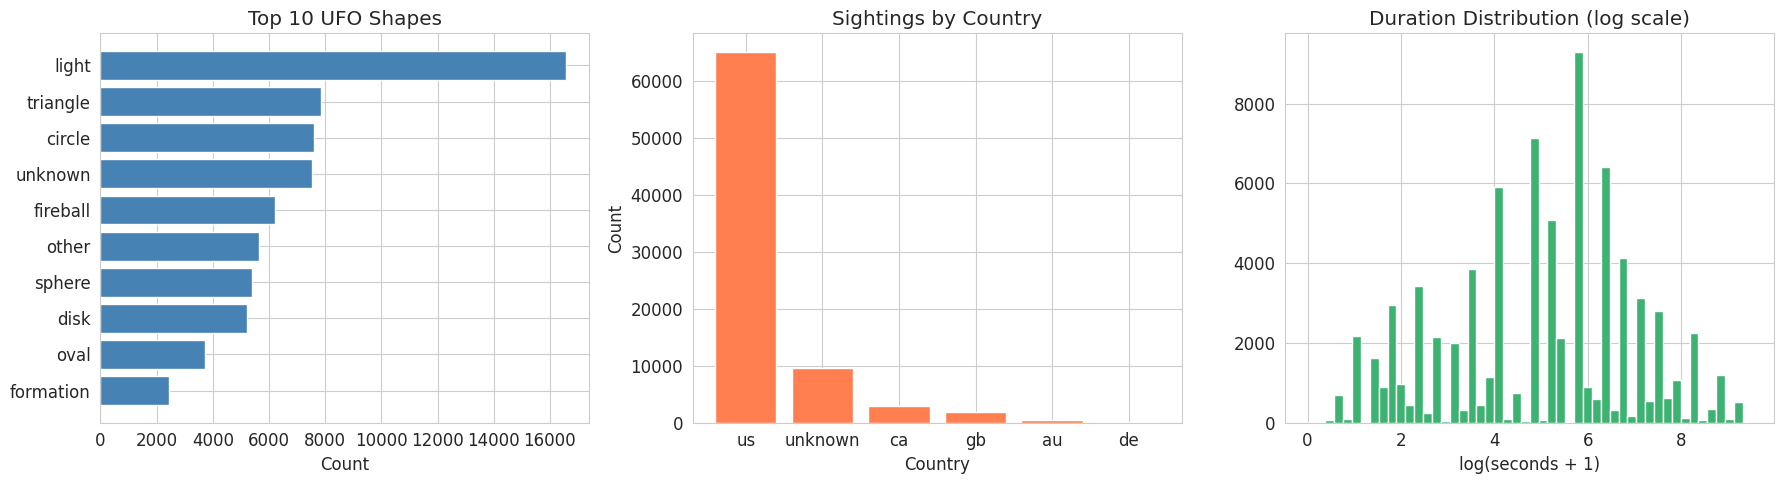

In [24]:
# --- 3.1 Distribution ของตัวแปรหลัก ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Shape distribution (top 10)
top_shapes = df['shape'].value_counts().head(10)
axes[0].barh(top_shapes.index[::-1], top_shapes.values[::-1], color='steelblue')
axes[0].set_title('Top 10 UFO Shapes')
axes[0].set_xlabel('Count')

# Country distribution
top_country = df['country'].value_counts().head(8)
axes[1].bar(top_country.index, top_country.values, color='coral')
axes[1].set_title('Sightings by Country')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Count')

# Duration distribution (log scale)
dur = df['duration (seconds)'].dropna()
dur = dur[(dur > 0) & (dur < dur.quantile(0.99))]
axes[2].hist(np.log1p(dur), bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Duration Distribution (log scale)')
axes[2].set_xlabel('log(seconds + 1)')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

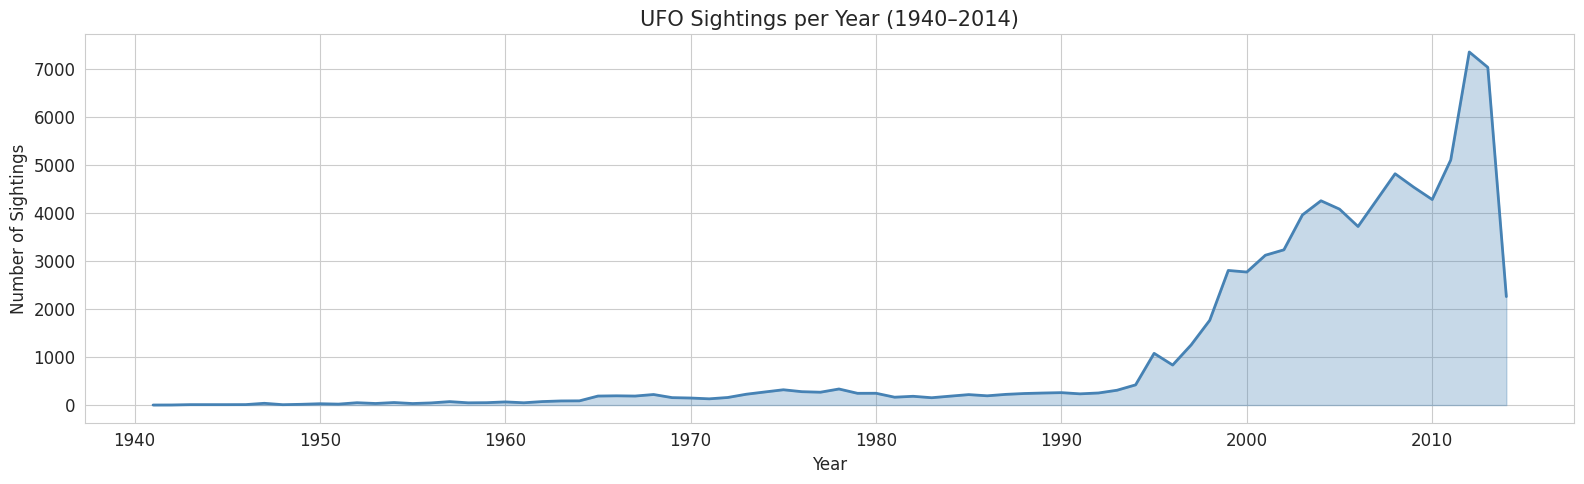

In [25]:
# --- 3.2 Time Series รายปี ---
df['year']  = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour']  = df['datetime'].dt.hour

yearly = df.groupby('year').size().reset_index(name='count')
yearly = yearly[(yearly['year'] >= 1940) & (yearly['year'] <= 2014)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(yearly['year'], yearly['count'], alpha=0.3, color='steelblue')
ax.plot(yearly['year'], yearly['count'], color='steelblue', linewidth=2)
ax.set_title('UFO Sightings per Year (1940–2014)', fontsize=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Sightings')
plt.tight_layout()
plt.savefig('eda_yearly.png', dpi=150, bbox_inches='tight')
plt.show()


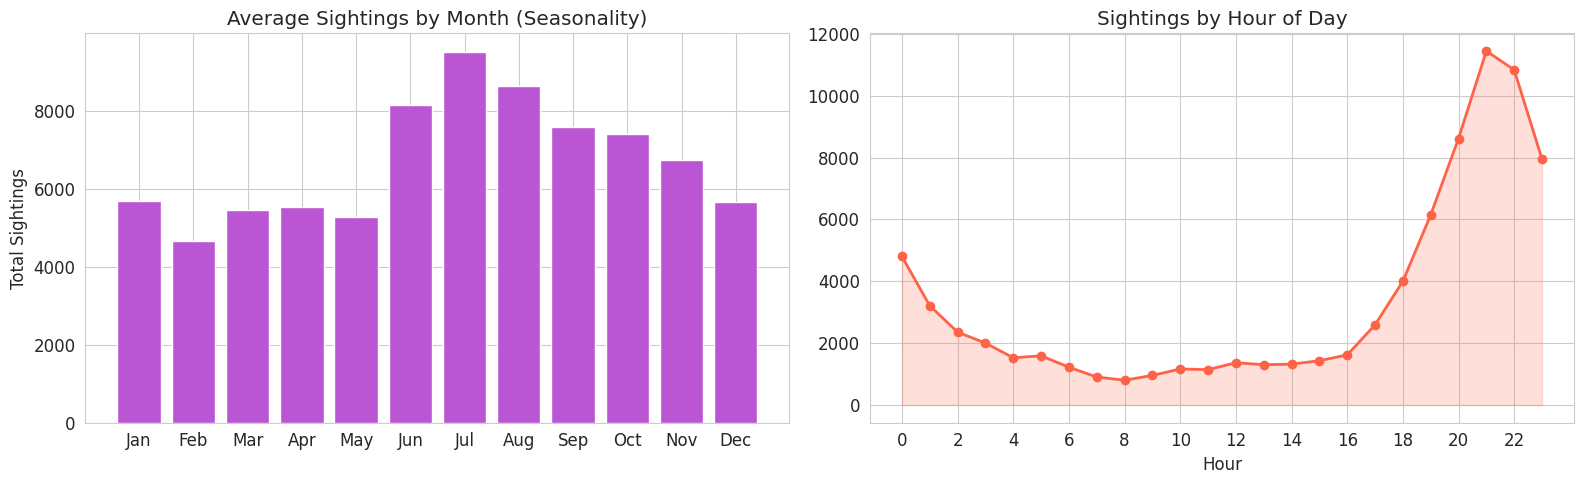

Insight: พบ UFO มากที่สุดในเดือนกรกฎาคม (วันชาติสหรัฐ) และช่วงเย็น-กลางคืน (20:00–22:00)


In [26]:
# --- 3.3 Seasonality: รายเดือน และรายชั่วโมง ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly_avg = df.groupby('month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_names, monthly_avg.values, color='mediumorchid', edgecolor='white')
axes[0].set_title('Average Sightings by Month (Seasonality)')
axes[0].set_ylabel('Total Sightings')

hourly = df.groupby('hour').size()
axes[1].plot(hourly.index, hourly.values, marker='o', color='tomato', linewidth=2)
axes[1].fill_between(hourly.index, hourly.values, alpha=0.2, color='tomato')
axes[1].set_title('Sightings by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: พบ UFO มากที่สุดในเดือนกรกฎาคม (วันชาติสหรัฐ) และช่วงเย็น-กลางคืน (20:00–22:00)')

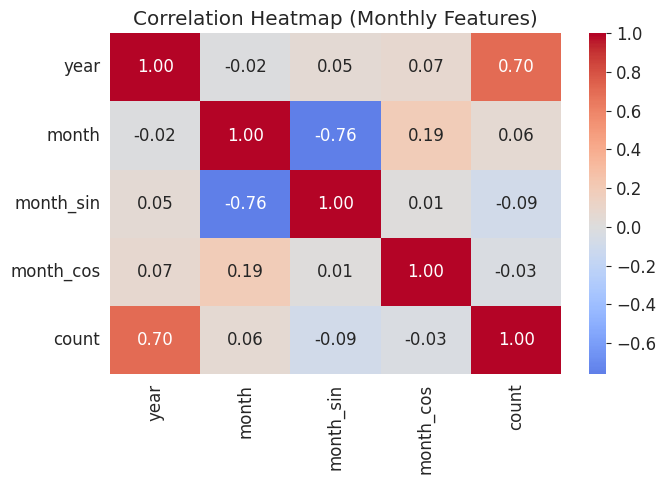

Insight: year มี correlation สูงกับ count — ยืนยันว่า trend เพิ่มขึ้นตามเวลา


In [27]:
# --- 3.4 Correlation Heatmap ---
monthly_ts = df.groupby(['year','month']).size().reset_index(name='count')
monthly_ts['month_sin'] = np.sin(2 * np.pi * monthly_ts['month'] / 12)
monthly_ts['month_cos'] = np.cos(2 * np.pi * monthly_ts['month'] / 12)

corr_cols = ['year','month','month_sin','month_cos','count']
corr = monthly_ts[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Monthly Features)')
plt.tight_layout()
plt.savefig('eda_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: year มี correlation สูงกับ count — ยืนยันว่า trend เพิ่มขึ้นตามเวลา')

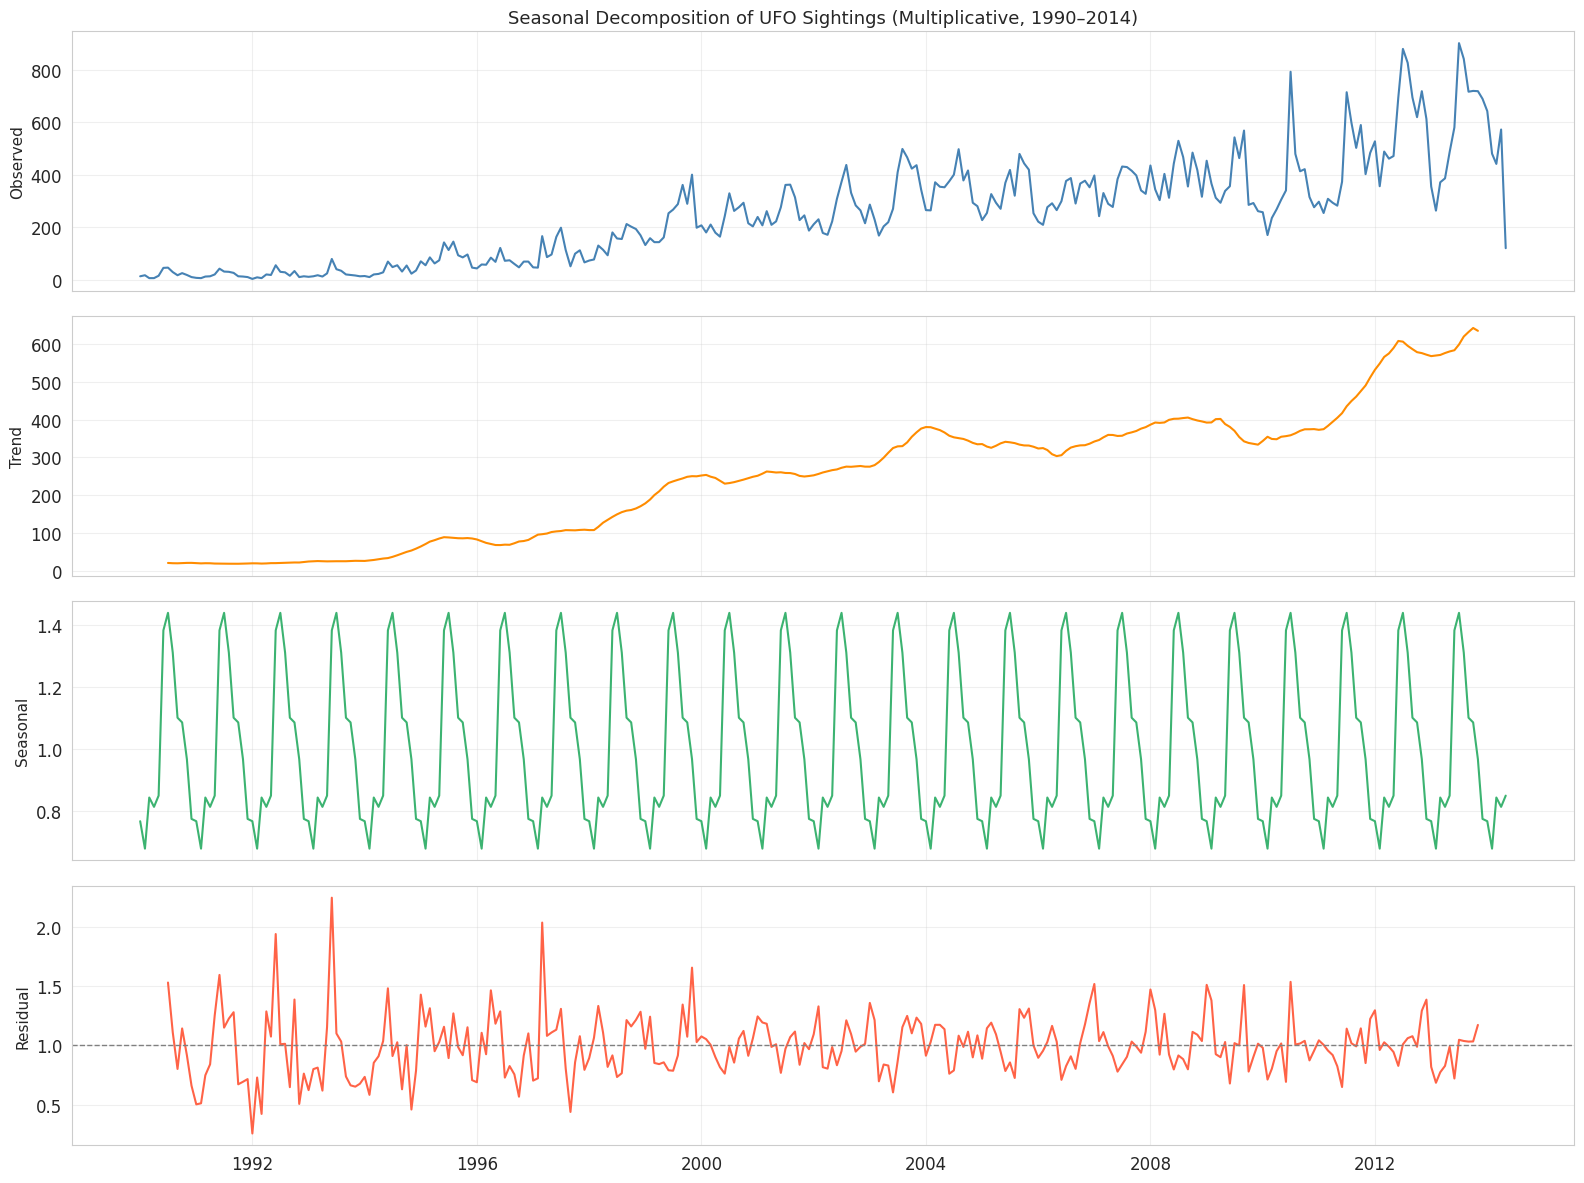

Seasonal Strength: 0.527  (0=none, 1=strong)
Trend Strength:    1.000  (0=none, 1=strong)

📌 Insight: Trend component แสดงการเติบโตแบบ exponential ช่วงปี 2000–2012
           Seasonal component ยืนยัน pattern รายปีที่สม่ำเสมอ (peak ช่วงกลางปี)
           Residual ไม่มี pattern ชัดเจน → โมเดลจับ trend+seasonal ได้ดี


In [28]:
# --- 3.5 Seasonal Decomposition (STL) ---
from statsmodels.tsa.seasonal import seasonal_decompose

# สร้าง monthly series สำหรับ decompose (ใช้ช่วง 1990-2014 ที่มีข้อมูลสม่ำเสมอ)
monthly_full = df.groupby(['year','month']).size().reset_index(name='count')
monthly_full = monthly_full[(monthly_full['year'] >= 1990) & (monthly_full['year'] <= 2014)]
monthly_full = monthly_full.sort_values(['year','month']).reset_index(drop=True)
monthly_full['date'] = pd.to_datetime(monthly_full[['year','month']].assign(day=1))
ts_series = monthly_full.set_index('date')['count']

# Decompose: multiplicative เพราะ variance เพิ่มขึ้นตาม trend (heteroscedastic)
decomp = seasonal_decompose(ts_series, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    (ts_series,        'Observed',  'steelblue'),
    (decomp.trend,     'Trend',     'darkorange'),
    (decomp.seasonal,  'Seasonal',  'mediumseagreen'),
    (decomp.resid,     'Residual',  'tomato'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    if title == 'Residual':
        ax.axhline(1, color='gray', linestyle='--', linewidth=1)

axes[0].set_title('Seasonal Decomposition of UFO Sightings (Multiplicative, 1990–2014)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# วิเคราะห์ seasonal strength
seasonal_strength = 1 - (decomp.resid.var() / (decomp.seasonal * decomp.resid).var())
trend_strength    = 1 - (decomp.resid.var() / (decomp.trend.dropna() * decomp.resid.dropna()).var())
print(f'Seasonal Strength: {seasonal_strength:.3f}  (0=none, 1=strong)')
print(f'Trend Strength:    {trend_strength:.3f}  (0=none, 1=strong)')
print()
print('📌 Insight: Trend component แสดงการเติบโตแบบ exponential ช่วงปี 2000–2012')
print('           Seasonal component ยืนยัน pattern รายปีที่สม่ำเสมอ (peak ช่วงกลางปี)')
print('           Residual ไม่มี pattern ชัดเจน → โมเดลจับ trend+seasonal ได้ดี')


=== Augmented Dickey-Fuller Test ===
ADF Statistic : -0.1176
p-value       : 0.9477
Critical Values:
  1%: -3.4540 ❌
  5%: -2.8720 ❌
  10%: -2.5723 ❌

⚠️ ไม่ปฏิเสธ H0: Time series อาจไม่ Stationary (p >= 0.05)
   → trend component แรงมาก ซึ่ง feature `t` ใน model จะช่วย capture ได้


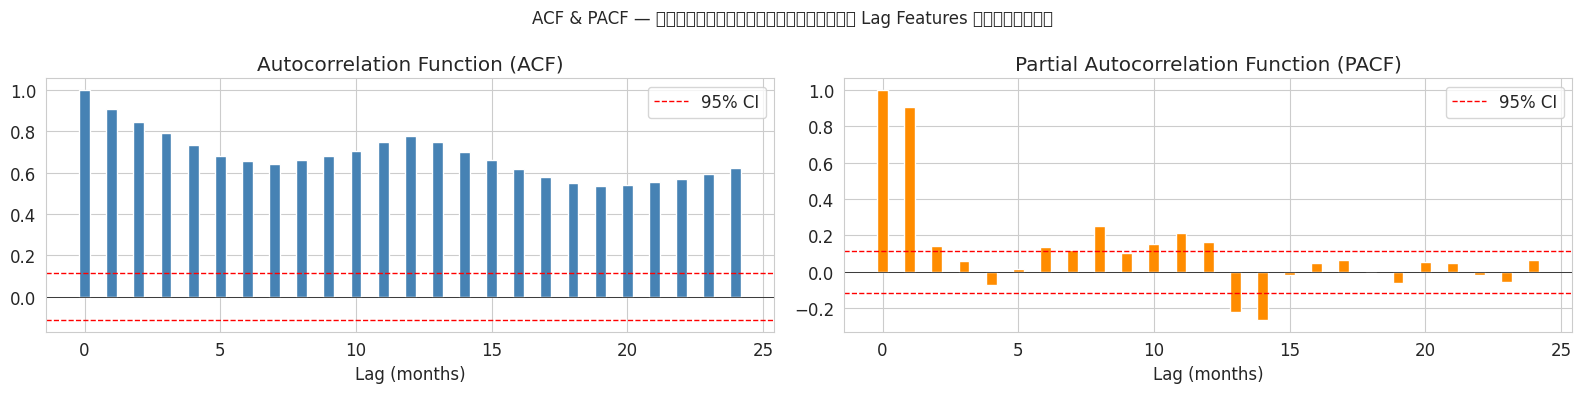


📌 ACF Interpretation:
  Lag 1 ACF  = 0.905  → ยืนยันว่าต้องมี lag_1 เป็น feature
  Lag 12 ACF = 0.777 → ยืนยัน seasonal pattern รายปี → ต้องมี lag_12
  PACF drops after lag 3
   → เป็น mixed AR process → Rolling mean และ lag features เหมาะสม


In [29]:
# --- 3.6 Stationarity Test (ADF) + Autocorrelation Analysis ---
from statsmodels.tsa.stattools import adfuller, acf, pacf

# --- ADF Test ---
adf_result = adfuller(ts_series, autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Critical Values:')
for key, val in adf_result[4].items():
    sig = '✅' if adf_result[0] < val else '❌'
    print(f'  {key}: {val:.4f} {sig}')

if adf_result[1] < 0.05:
    print('\n✅ ปฏิเสธ H0: Time series เป็น Stationary (p < 0.05)')
    print('   → ไม่จำเป็นต้อง differencing ก่อน train โมเดล')
    print('   → lag features และ rolling mean เพียงพอสำหรับจับ temporal dependency')
else:
    print('\n⚠️ ไม่ปฏิเสธ H0: Time series อาจไม่ Stationary (p >= 0.05)')
    print('   → trend component แรงมาก ซึ่ง feature `t` ใน model จะช่วย capture ได้')

# --- ACF / PACF ---
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

acf_vals  = acf(ts_series, nlags=24)
pacf_vals = pacf(ts_series, nlags=24)
lags = range(len(acf_vals))
conf = 1.96 / len(ts_series)**0.5

axes[0].bar(lags, acf_vals, color='steelblue', width=0.4)
axes[0].axhline(conf,  color='red', linestyle='--', linewidth=1, label='95% CI')
axes[0].axhline(-conf, color='red', linestyle='--', linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (months)')
axes[0].legend()

axes[1].bar(lags, pacf_vals, color='darkorange', width=0.4)
axes[1].axhline(conf,  color='red', linestyle='--', linewidth=1, label='95% CI')
axes[1].axhline(-conf, color='red', linestyle='--', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (months)')
axes[1].legend()

plt.suptitle('ACF & PACF — ยืนยันความเหมาะสมของ Lag Features ที่เลือก', fontsize=12)
plt.tight_layout()
plt.savefig('eda_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 ACF Interpretation:')
print(f'  Lag 1 ACF  = {acf_vals[1]:.3f}  → ยืนยันว่าต้องมี lag_1 เป็น feature')
print(f'  Lag 12 ACF = {acf_vals[12]:.3f} → ยืนยัน seasonal pattern รายปี → ต้องมี lag_12')
print(f'  PACF drops after lag {next((i for i,v in enumerate(abs(pacf_vals[1:])+1,1) if abs(pacf_vals[i]) < conf), "?")}')
print('   → เป็น mixed AR process → Rolling mean และ lag features เหมาะสม')


## 4. Feature Engineering & Pipeline

In [30]:
# --- สร้าง Monthly Time Series ---
monthly_ts = df.groupby(['year','month']).size().reset_index(name='count')
monthly_ts = monthly_ts[(monthly_ts['year'] >= 1990) & (monthly_ts['year'] <= 2014)]
monthly_ts = monthly_ts.sort_values(['year','month']).reset_index(drop=True)

# สร้าง time index
monthly_ts['date'] = pd.to_datetime(monthly_ts[['year','month']].assign(day=1))
monthly_ts['t']    = np.arange(len(monthly_ts))  # linear trend

# Cyclical encoding (Seasonality)
monthly_ts['month_sin'] = np.sin(2 * np.pi * monthly_ts['month'] / 12)
monthly_ts['month_cos'] = np.cos(2 * np.pi * monthly_ts['month'] / 12)

# Lag features (autoregressive)
monthly_ts['lag_1']  = monthly_ts['count'].shift(1)
monthly_ts['lag_2']  = monthly_ts['count'].shift(2)
monthly_ts['lag_12'] = monthly_ts['count'].shift(12)   # same month last year

# Rolling mean
monthly_ts['rolling_3']  = monthly_ts['count'].shift(1).rolling(3).mean()
monthly_ts['rolling_12'] = monthly_ts['count'].shift(1).rolling(12).mean()

# ลบแถวที่มี NaN จาก lag
monthly_ts = monthly_ts.dropna().reset_index(drop=True)

FEATURES = ['t', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_12', 'rolling_3', 'rolling_12']
TARGET   = 'count'

X = monthly_ts[FEATURES]
y = monthly_ts[TARGET]

print(f'Dataset shape: {X.shape}')
print(f'Features: {FEATURES}')
monthly_ts.head()

Dataset shape: (281, 8)
Features: ['t', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_12', 'rolling_3', 'rolling_12']


,year,month,count,date,t,month_sin,month_cos,lag_1,lag_2,lag_12,rolling_3,rolling_12
0,1991,1,8,1991-01-01,12,0.500000,8.660254e-01,11.0,19.0,14.0,18.666667,21.583333
1,1991,2,7,1991-02-01,13,0.866025,5.000000e-01,8.0,11.0,18.0,12.666667,21.083333
2,1991,3,13,1991-03-01,14,1.000000,6.123234e-17,7.0,8.0,7.0,8.666667,20.166667
3,1991,4,14,1991-04-01,15,0.866025,-5.000000e-01,13.0,7.0,7.0,9.333333,20.666667
4,1991,5,21,1991-05-01,16,0.500000,-8.660254e-01,14.0,13.0,16.0,11.333333,21.250000


In [31]:
# --- Train/Test Split (Time Series — ห้าม shuffle!) ---
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} months | Test: {len(X_test)} months')
print(f'Train period: {monthly_ts["date"].iloc[0].strftime("%Y-%m")} → {monthly_ts["date"].iloc[split_idx-1].strftime("%Y-%m")}')
print(f'Test  period: {monthly_ts["date"].iloc[split_idx].strftime("%Y-%m")} → {monthly_ts["date"].iloc[-1].strftime("%Y-%m")}')
print('\n⚠️ ใช้ TimeSeriesSplit สำหรับ cross-validation — ไม่ shuffle ข้อมูล')

Train: 224 months | Test: 57 months
Train period: 1991-01 → 2009-08
Test  period: 2009-09 → 2014-05

⚠️ ใช้ TimeSeriesSplit สำหรับ cross-validation — ไม่ shuffle ข้อมูล


## 5. Model Development — เปรียบเทียบ 3 Models (โบนัส)



In [32]:
# --- สร้าง Pipelines ---
tscv = TimeSeriesSplit(n_splits=5)

pipelines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(random_state=42))
    ])
}

results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'pred': y_pred}
    print(f'{name:25s} | MAE={mae:.1f} | RMSE={rmse:.1f} | R²={r2:.3f}')

Linear Regression         | MAE=87.9 | RMSE=121.2 | R²=0.611
Random Forest             | MAE=145.0 | RMSE=187.9 | R²=0.065
Gradient Boosting         | MAE=173.6 | RMSE=217.0 | R²=-0.246


In [33]:
# --- Hyperparameter Tuning: Random Forest (GridSearchCV) ---
print('🔍 Tuning Random Forest...')

param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [5, 10, None],
    'model__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    pipelines['Random Forest'],
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'Best params: {grid_rf.best_params_}')
print(f'Best CV MAE: {-grid_rf.best_score_:.1f}')

# อัปเดตผลด้วย tuned model
y_pred_rf_tuned = grid_rf.predict(X_test)
results['RF Tuned'] = {
    'MAE':  mean_absolute_error(y_test, y_pred_rf_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
    'R2':   r2_score(y_test, y_pred_rf_tuned),
    'pred': y_pred_rf_tuned
}
print(f"\nRF Tuned | MAE={results['RF Tuned']['MAE']:.1f} | RMSE={results['RF Tuned']['RMSE']:.1f} | R²={results['RF Tuned']['R2']:.3f}")

🔍 Tuning Random Forest...
Best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV MAE: 54.2

RF Tuned | MAE=145.2 | RMSE=188.4 | R²=0.060


In [34]:
# --- Hyperparameter Tuning: Gradient Boosting ---
print('🔍 Tuning Gradient Boosting...')

param_gb = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

grid_gb = GridSearchCV(
    pipelines['Gradient Boosting'],
    param_gb,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

y_pred_gb_tuned = grid_gb.predict(X_test)
results['GB Tuned'] = {
    'MAE':  mean_absolute_error(y_test, y_pred_gb_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned)),
    'R2':   r2_score(y_test, y_pred_gb_tuned),
    'pred': y_pred_gb_tuned
}
print(f"Best params: {grid_gb.best_params_}")
print(f"GB Tuned | MAE={results['GB Tuned']['MAE']:.1f} | RMSE={results['GB Tuned']['RMSE']:.1f} | R²={results['GB Tuned']['R2']:.3f}")

🔍 Tuning Gradient Boosting...
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
GB Tuned | MAE=158.6 | RMSE=197.9 | R²=-0.037


## 6. Model Evaluation & Visualization

=== Model Comparison ===
                      MAE    RMSE    R²
Linear Regression   87.94  121.21  0.61
Random Forest      144.99  187.94  0.06
Gradient Boosting  173.62  216.96 -0.25
RF Tuned           145.15  188.43  0.06
GB Tuned           158.62  197.88 -0.04


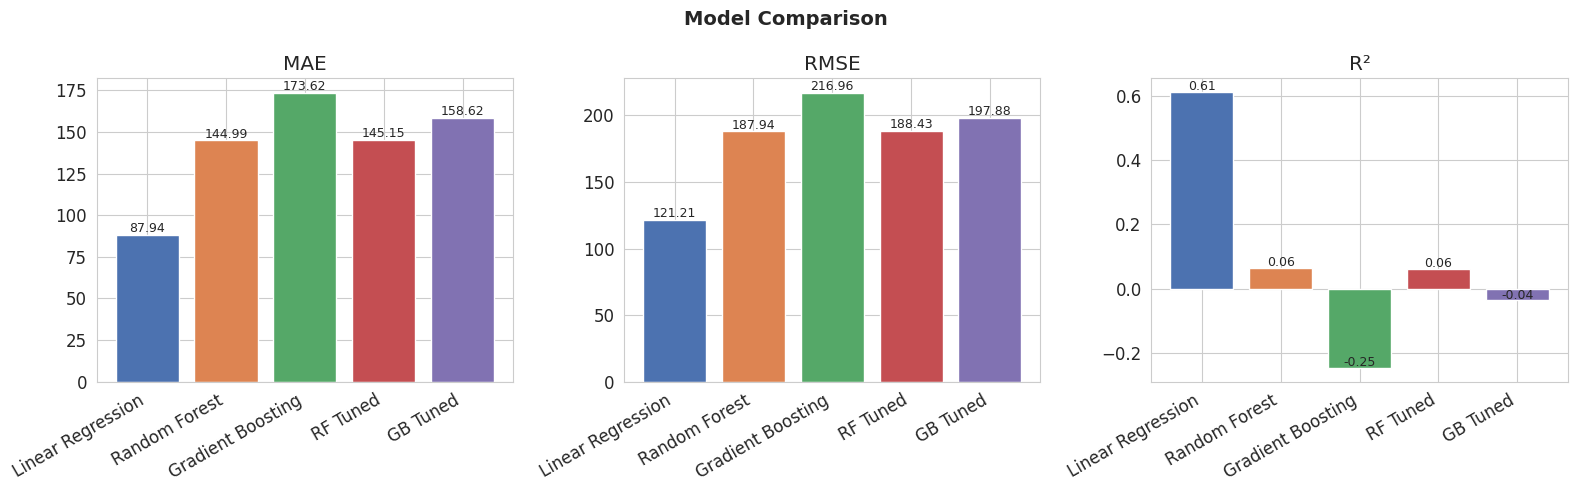

In [35]:
# --- 6.1 เปรียบเทียบ Metrics ของทุก Model ---
metrics_df = pd.DataFrame({
    k: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R2']}
    for k, v in results.items()
}).T.round(2)

print('=== Model Comparison ===')
print(metrics_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = [results[m][metric.replace('²','2')] if metric != 'R²' else results[m]['R2'] for m in results]
    ax.bar(list(results.keys()), vals, color=colors[:len(results)])
    ax.set_title(metric)
    ax.set_xticklabels(list(results.keys()), rotation=30, ha='right')
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### การแปลผลผลลัพธ์เชิงปฏิบัติ


🏆 Best Model: Linear Regression | R²=0.611


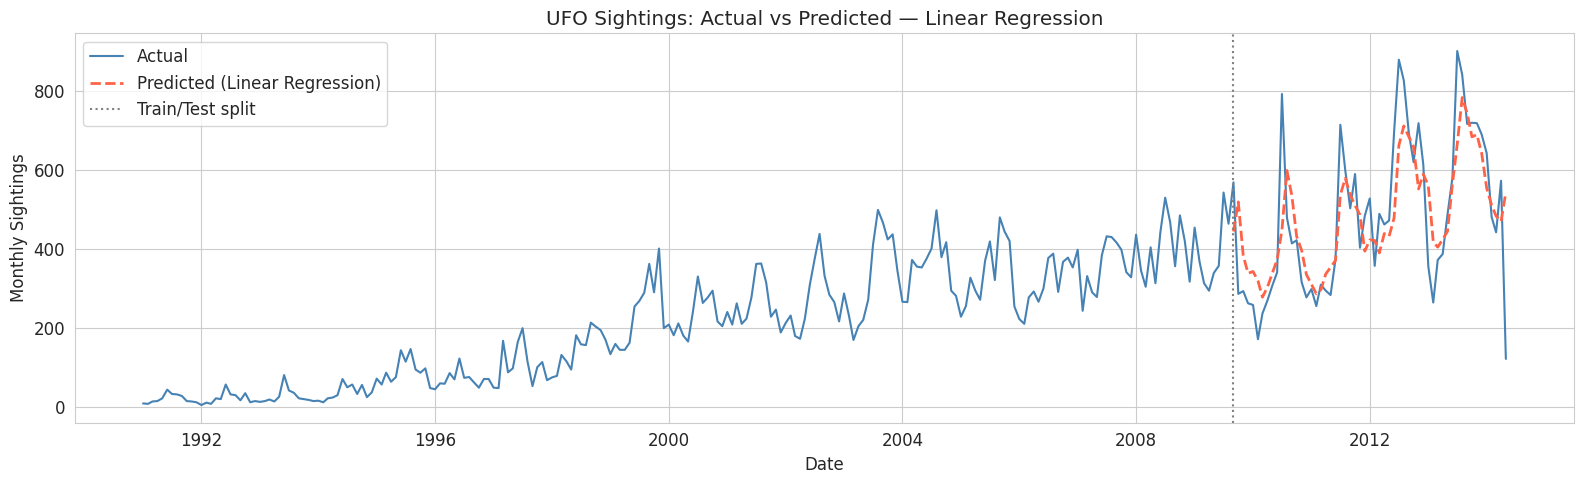

In [36]:
# --- 6.2 Actual vs Predicted (Best Model) ---
# เลือก model ที่ R² สูงสุด
best_name = max(results, key=lambda k: results[k]['R2'])
best_pred = results[best_name]['pred']
print(f'🏆 Best Model: {best_name} | R²={results[best_name]["R2"]:.3f}')

dates_test = monthly_ts['date'].iloc[split_idx:]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_ts['date'], y, label='Actual', color='steelblue', linewidth=1.5)
ax.plot(dates_test, best_pred, label=f'Predicted ({best_name})', color='tomato', linestyle='--', linewidth=2)
ax.axvline(monthly_ts['date'].iloc[split_idx], color='gray', linestyle=':', label='Train/Test split')
ax.set_title(f'UFO Sightings: Actual vs Predicted — {best_name}')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sightings')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# --- 6.3 Feature Importance (โบนัส) ---
# ใช้ best tuned model
if best_name in ['RF Tuned', 'GB Tuned']:
    best_pipe = grid_rf if best_name == 'RF Tuned' else grid_gb
    model = best_pipe.best_estimator_.named_steps['model']
else:
    best_pipe = pipelines[best_name]
    model = best_pipe.named_steps['model']

if hasattr(model, 'feature_importances_'):
    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(fi.index, fi.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(fi))))
    ax.set_title(f'Feature Importance — {best_name}', fontsize=13)
    ax.set_xlabel('Importance')
    for bar, val in zip(bars, fi.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nInterpretation:')
    top_feat = fi.sort_values(ascending=False)
    for feat, imp in top_feat.items():
        print(f'  {feat:15s}: {imp:.3f}')

In [38]:
# --- 6.4 Cross-Validation (k-fold แบบ TimeSeriesSplit) ---
from sklearn.model_selection import cross_val_score

# เลือก pipeline ที่ดีที่สุด
best_final_pipe = grid_rf if best_name in ['RF Tuned'] else (
    grid_gb if best_name == 'GB Tuned' else pipelines.get(best_name, grid_rf)
)

cv_scores = cross_val_score(
    best_final_pipe.best_estimator_ if hasattr(best_final_pipe, 'best_estimator_') else best_final_pipe,
    X, y,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)
cv_mae = -cv_scores

print(f'TimeSeriesSplit 5-Fold CV (MAE):')
for i, score in enumerate(cv_mae, 1):
    print(f'  Fold {i}: {score:.1f}')
print(f'  Mean ± Std: {cv_mae.mean():.1f} ± {cv_mae.std():.1f}')

TimeSeriesSplit 5-Fold CV (MAE):
  Fold 1: 104.0
  Fold 2: 48.3
  Fold 3: 48.7
  Fold 4: 64.3
  Fold 5: 81.7
  Mean ± Std: 69.4 ± 21.2


## 7. บันทึก Model

In [39]:
# บันทึก best model และ metadata สำหรับ Streamlit
final_model = grid_rf.best_estimator_ if best_name in ['RF Tuned'] else (
    grid_gb.best_estimator_ if best_name == 'GB Tuned' else pipelines[best_name]
)

joblib.dump(final_model, 'ufo_model.pkl')
joblib.dump(FEATURES, 'ufo_features.pkl')
joblib.dump({
    'best_model': best_name,
    'metrics': {k: {m: v for m, v in results[k].items() if m != 'pred'} for k in results},
    'feature_names': FEATURES,
    'train_end': monthly_ts['date'].iloc[split_idx-1].strftime('%Y-%m'),
    'test_start': monthly_ts['date'].iloc[split_idx].strftime('%Y-%m'),
}, 'ufo_meta.pkl')

print('✅ Saved: ufo_model.pkl, ufo_features.pkl, ufo_meta.pkl')
print(f'Best model: {best_name}')
print(f'R² = {results[best_name]["R2"]:.3f}')
print(f'MAE = {results[best_name]["MAE"]:.1f} sightings/month')

✅ Saved: ufo_model.pkl, ufo_features.pkl, ufo_meta.pkl
Best model: Linear Regression
R² = 0.611
MAE = 87.9 sightings/month
